# VALLE NUEVO

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa as tsa
import statsmodels as sm
from datetime import datetime
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

#Tensorflow
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential,save_model,load_model
from keras.layers import Dense
from keras.layers import LSTM
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import keras

#Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## Carga de archivos

In [2]:
train = pd.read_csv("../Datos/train.csv")
test = pd.read_csv("../Datos/test.csv")

In [3]:
#filtrar turistas y excursionistas
train = train[
    train["Tipo de Viajero"].isin(
        ["Turista","Excursionista"]
    )
]

test = test[
    test["Tipo de Viajero"].isin(
        ["Turista","Excursionista"]
    )
]

In [4]:
tf.random.set_seed(123)

train["Fecha"] = pd.to_datetime(train["Fecha"])

print("\nParsed Data:")
print(train.head())


Parsed Data:
    Año  Mes cod  Mes    Vía      Frontera            País  \
0  2009        1  Ene  Aérea  01 La Aurora         Albania   
1  2009        1  Ene  Aérea  01 La Aurora        Alemania   
2  2009        1  Ene  Aérea  01 La Aurora          Angola   
3  2009        1  Ene  Aérea  01 La Aurora  Arabia Saudita   
4  2009        1  Ene  Aérea  01 La Aurora         Argelia   

                   Región              Región dos       Regiones OMT  \
0          OTROS EUROPEOS                  Europa  EUROPA MERIDIONAL   
1                  EUROPA                  Europa  EUROPA OCCIDENTAL   
2  OTROS PAISES DEL MUNDO  Otros Paises Del Mundo     ÁFRICA CENTRAL   
3     OTROS ORIENTE MEDIO           Oriente Medio      ORIENTE MEDIO   
4  OTROS PAISES DEL MUNDO  Otros Paises Del Mundo   ÁFRICA DEL NORTE   

        MCEO Agrupación Residencia Tipo de Viajero  Viajero      Fecha  
0   08 OTROS                Europa         Turista      1.0 2009-01-01  
1  04 EUROPA                Europa

In [5]:
test["Fecha"] = pd.to_datetime(test["Fecha"])

print("\nParsed Data:")
print(test.head())


Parsed Data:
    Año  Mes cod  Mes    Vía      Frontera       País           Región  \
1  2021        4  Abr  Aérea  01 La Aurora   Alemania           EUROPA   
2  2021        4  Abr  Aérea  01 La Aurora  Argentina  AMÉRICA DEL SUR   
4  2021        4  Abr  Aérea  01 La Aurora    Austria           EUROPA   
5  2021        4  Abr  Aérea  01 La Aurora    Bahamas  OTROS CARIBEÑOS   
6  2021        4  Abr  Aérea  01 La Aurora   Barbados  OTROS CARIBEÑOS   

                    Región dos       Regiones OMT           MCEO  \
1                       Europa  EUROPA OCCIDENTAL      04 EUROPA   
2  América Del Sur y el Caribe    AMÉRICA DEL SUR  03 SUDAMÉRICA   
4                       Europa  EUROPA OCCIDENTAL       08 OTROS   
5  América Del Sur y el Caribe          EL CARIBE       08 OTROS   
6  América Del Sur y el Caribe          EL CARIBE       08 OTROS   

  Agrupación Residencia Tipo de Viajero     Viajero      Fecha  
1                Europa         Turista  229.534884 2021-04-01  
2 

## Serie

In [6]:
train_serie = (
    train[
        train["Frontera"]=="07 Valle Nuevo"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
    .asfreq("MS")
)

test_serie = (
    test[
        test["Frontera"]=="07 Valle Nuevo"
    ]
    .groupby("Fecha")["Viajero"]
    .sum()
    .asfreq("MS")
)

In [7]:
train_serie.to_csv("valle_nuevo_train.csv", header=["Viajero"])
test_serie.to_csv("valle_nuevo_test.csv", header=["Viajero"])

print("Archivos guardados correctamente.")

Archivos guardados correctamente.


In [7]:
print(type(train_serie))
print(train_serie.head())
print(train_serie.index)

<class 'pandas.core.series.Series'>
Fecha
2009-01-01    16204.815818
2009-02-01    17754.437037
2009-03-01    27236.744710
2009-04-01    36564.959498
2009-05-01    26924.008001
Freq: MS, Name: Viajero, dtype: float64
DatetimeIndex(['2009-01-01', '2009-02-01', '2009-03-01', '2009-04-01',
               '2009-05-01', '2009-06-01', '2009-07-01', '2009-08-01',
               '2009-09-01', '2009-10-01',
               ...
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01',
               '2021-02-01', '2021-03-01'],
              dtype='datetime64[ns]', name='Fecha', length=147, freq='MS')


## Info de la serie

In [8]:
print("Inicio:", train_serie.index.min())

print("Fin:", train_serie.index.max())

print("Frecuencia:", train_serie.index.freq)

Inicio: 2009-01-01 00:00:00
Fin: 2021-03-01 00:00:00
Frecuencia: <MonthBegin>


## Gráfica de la serie

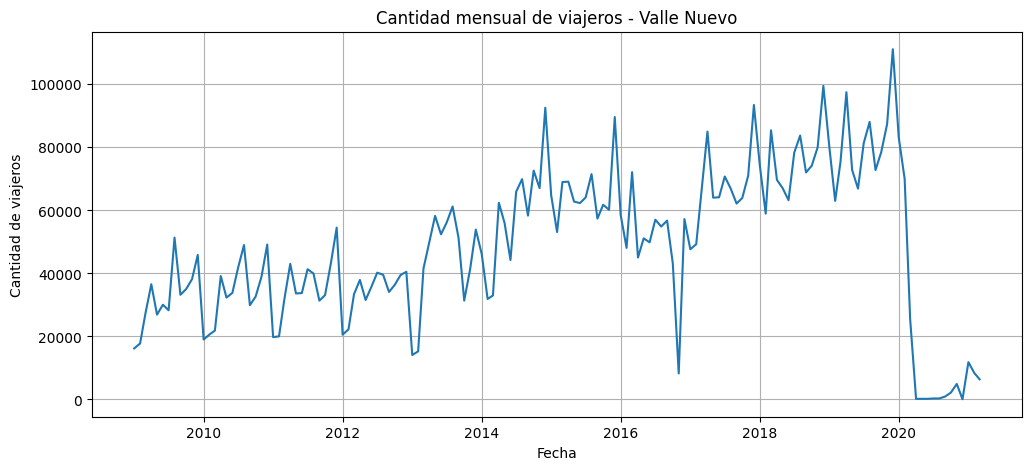

In [12]:
plt.figure(figsize=(12,5))

plt.plot(train_serie.index, train_serie.values)

plt.title("Cantidad mensual de viajeros - Valle Nuevo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.grid(True)

plt.show()

In [10]:
mediaMovil = train_serie.rolling(window=12).mean()
deMovil = train_serie.rolling(window=12).std()

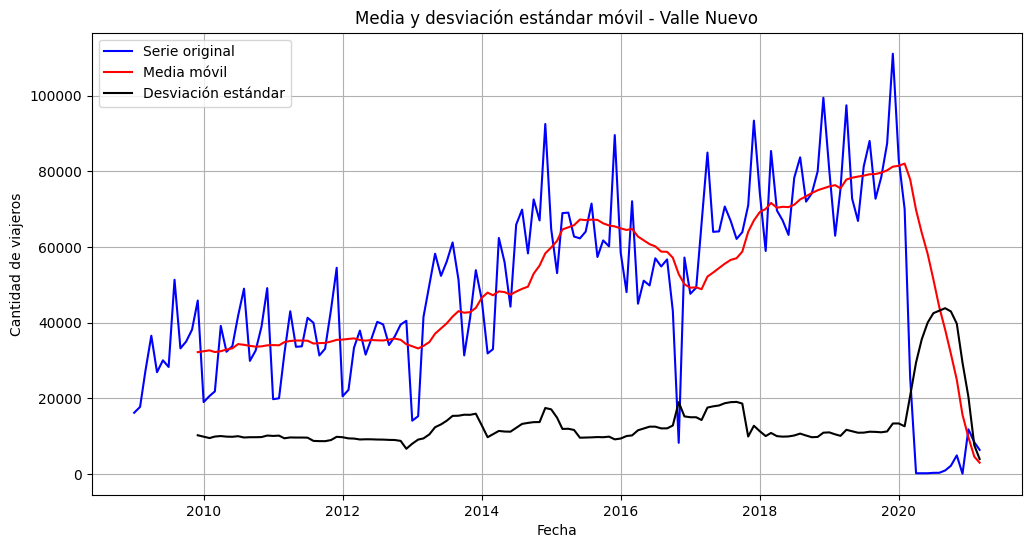

In [13]:
plt.figure(figsize=(12,6))

plt.plot(train_serie.index, train_serie.values,
         label="Serie original", color="blue")

plt.plot(mediaMovil.index, mediaMovil,
         label="Media móvil", color="red")

plt.plot(deMovil.index, deMovil,
         label="Desviación estándar", color="black")

plt.title("Media y desviación estándar móvil - Valle Nuevo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")

plt.legend()

plt.grid(True)

plt.show()

## Descomposición de la serie

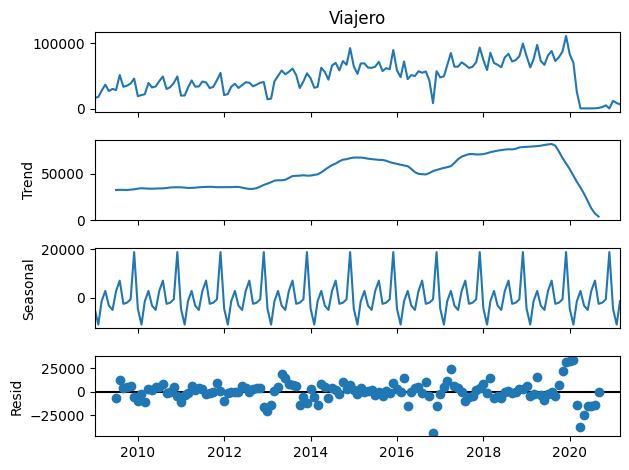

In [14]:
descomposicion = seasonal_decompose(train_serie)
descomposicion.plot();

## Transformación de la serie

In [15]:
print('Resultados del Test de Dickey Fuller')
dfTest = adfuller(train_serie, autolag='AIC')
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller
Estadístico de prueba         -1.831822
p-value                        0.364781
# de retardos usados          12.000000
# de observaciones usadas    134.000000
Critical Value (1%)           -3.480119
Critical Value (5%)           -2.883362
Critical Value (10%)          -2.578407
dtype: float64


In [16]:
print('Resultados del Test de Dickey Fuller para una diferenciación de la serie')
train_serie_diff = train_serie.diff()
train_serie_diff.fillna(0,inplace=True)
dfTest = adfuller(train_serie_diff)
salidaDf = pd.Series(dfTest[0:4], index=['Estadístico de prueba','p-value','# de retardos usados','# de observaciones usadas'])
for key,value in dfTest[4].items():
        salidaDf['Critical Value (%s)'%key] = value
print(salidaDf)

Resultados del Test de Dickey Fuller para una diferenciación de la serie
Estadístico de prueba         -3.680650
p-value                        0.004394
# de retardos usados          11.000000
# de observaciones usadas    135.000000
Critical Value (1%)           -3.479743
Critical Value (5%)           -2.883198
Critical Value (10%)          -2.578320
dtype: float64


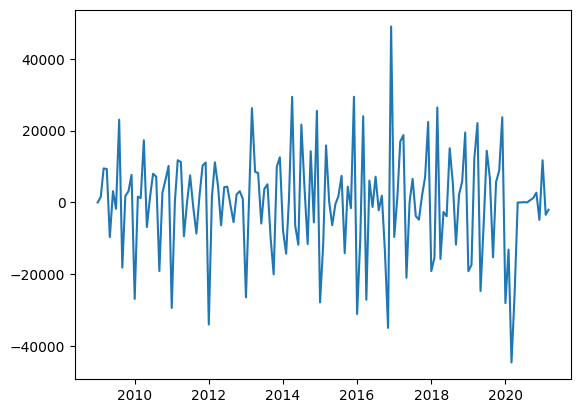

In [17]:
plt.plot(train_serie_diff)

## Es estacionaria

<Figure size 1000x500 with 0 Axes>

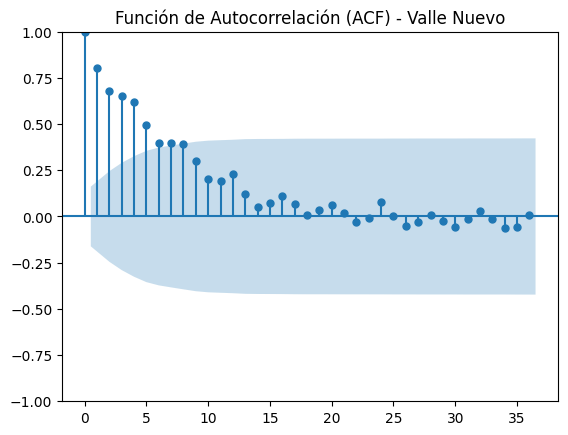

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(train_serie, lags=36)

plt.title("Función de Autocorrelación (ACF) - Valle Nuevo")

plt.show()

<Figure size 1000x500 with 0 Axes>

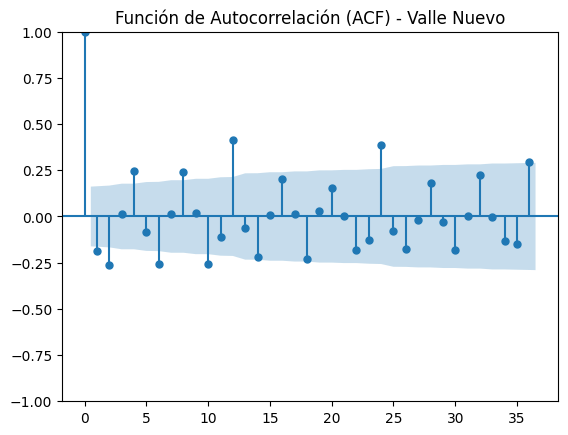

In [20]:
plt.figure(figsize=(10,5))

plot_acf(train_serie_diff, lags=36)

plt.title("Función de Autocorrelación (ACF) - Valle Nuevo")

plt.show()

## Selección de parámetros

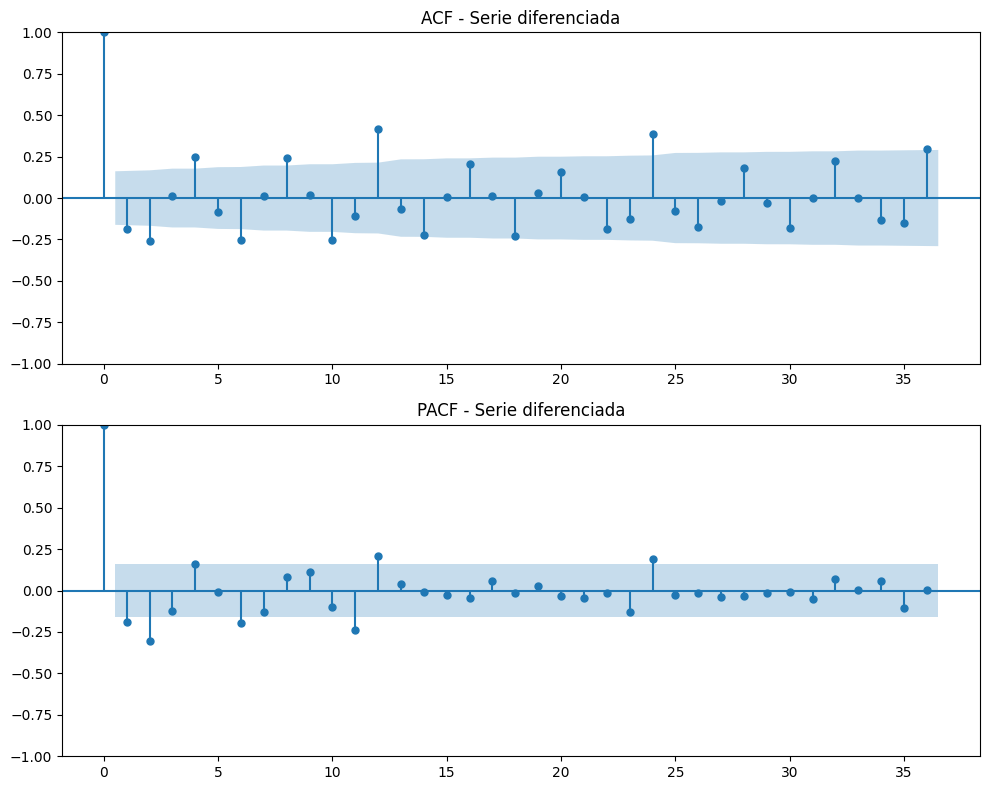

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(10,8))

plot_acf(train_serie_diff, lags=36, ax=ax[0])
ax[0].set_title("ACF - Serie diferenciada")

plot_pacf(train_serie_diff, lags=36, ax=ax[1])
ax[1].set_title("PACF - Serie diferenciada")

plt.tight_layout()
plt.show()

## Creación de modelos

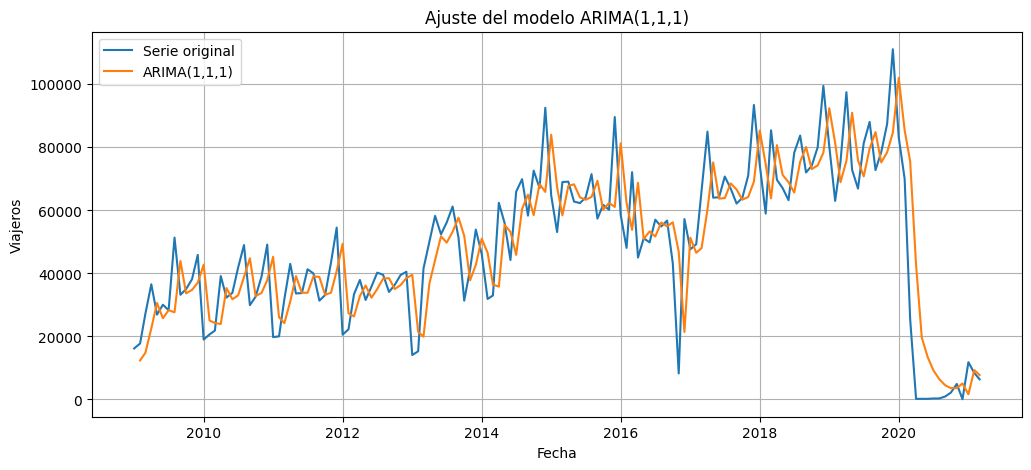

In [22]:
from statsmodels.tsa.arima.model import ARIMA

modelo_111 = ARIMA(train_serie, order=(1,1,1)).fit()

ajuste = modelo_111.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(1,1,1)")

plt.title("Ajuste del modelo ARIMA(1,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

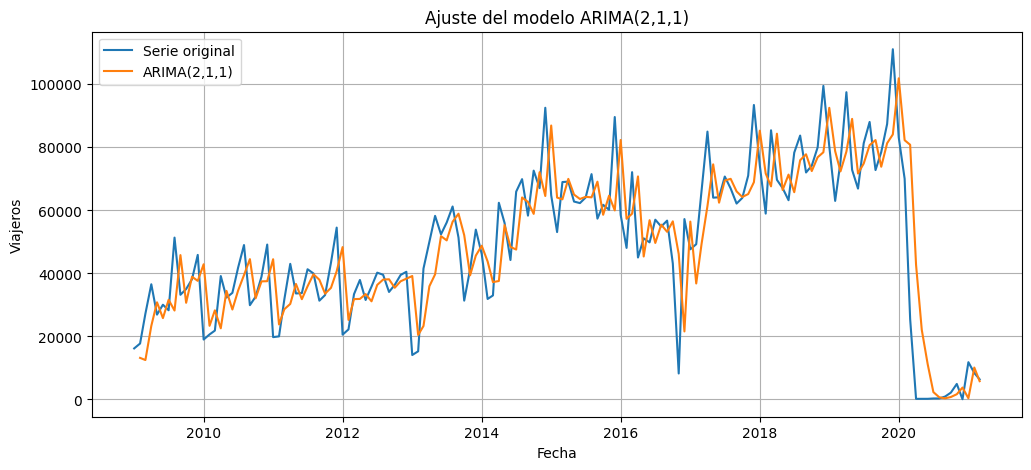

In [23]:
modelo_211 = ARIMA(train_serie, order=(2,1,1)).fit()

ajuste = modelo_211.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(2,1,1)")

plt.title("Ajuste del modelo ARIMA(2,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

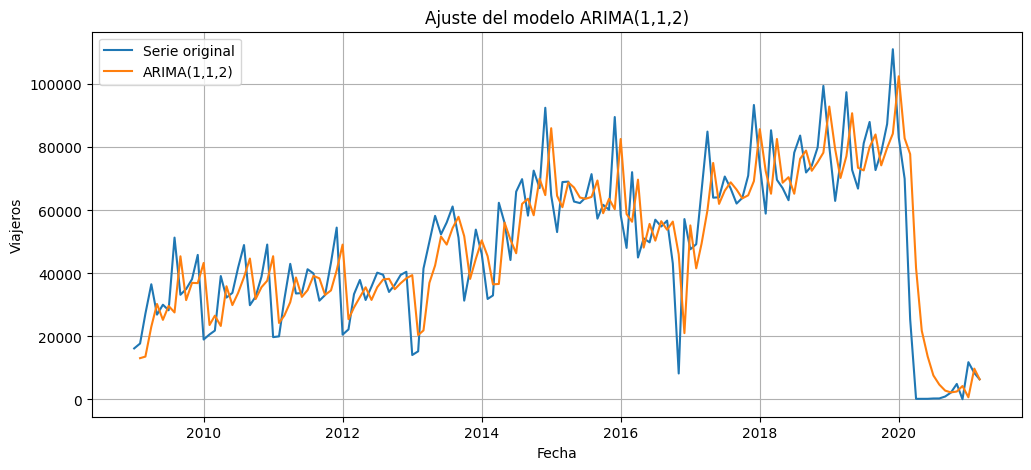

In [24]:
modelo_112 = ARIMA(train_serie, order=(1,1,2)).fit()

ajuste = modelo_112.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(1,1,2)")

plt.title("Ajuste del modelo ARIMA(1,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

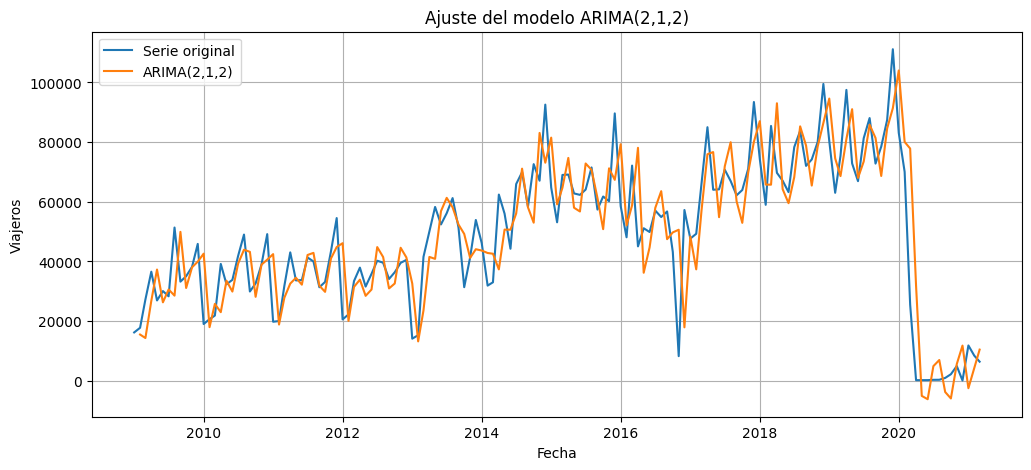

In [25]:
modelo_212 = ARIMA(train_serie, order=(2,1,2)).fit()

ajuste = modelo_212.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(2,1,2)")

plt.title("Ajuste del modelo ARIMA(2,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

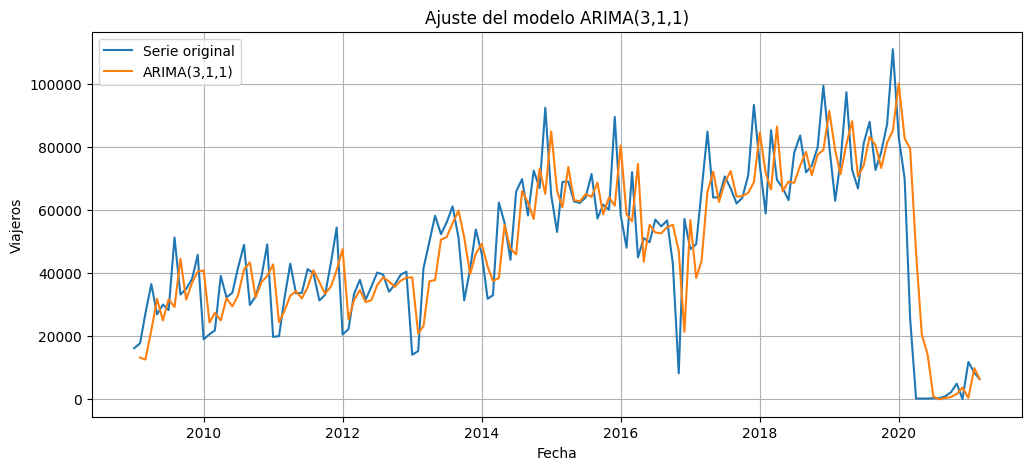

In [26]:
modelo_311 = ARIMA(train_serie, order=(3,1,1)).fit()

ajuste = modelo_311.predict(
    start=train_serie.index[1],
    end=train_serie.index[-1],
    typ="levels"
)

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Serie original")
plt.plot(ajuste, label="ARIMA(3,1,1)")

plt.title("Ajuste del modelo ARIMA(3,1,1)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()


Modelo ARIMA(1, 1, 1)


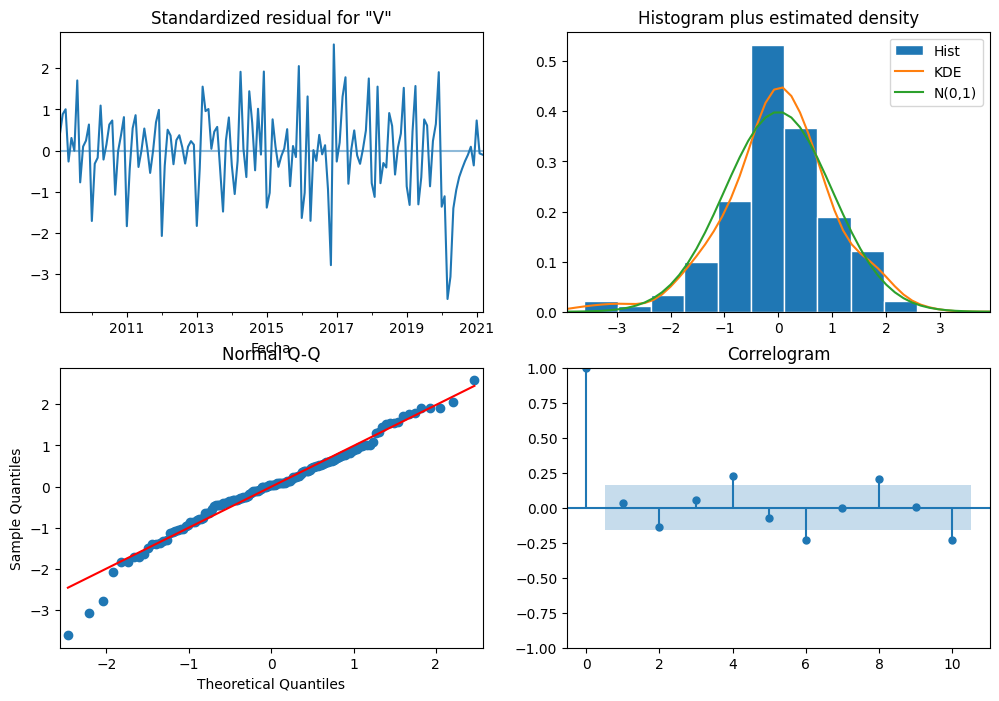


Modelo ARIMA(2, 1, 1)


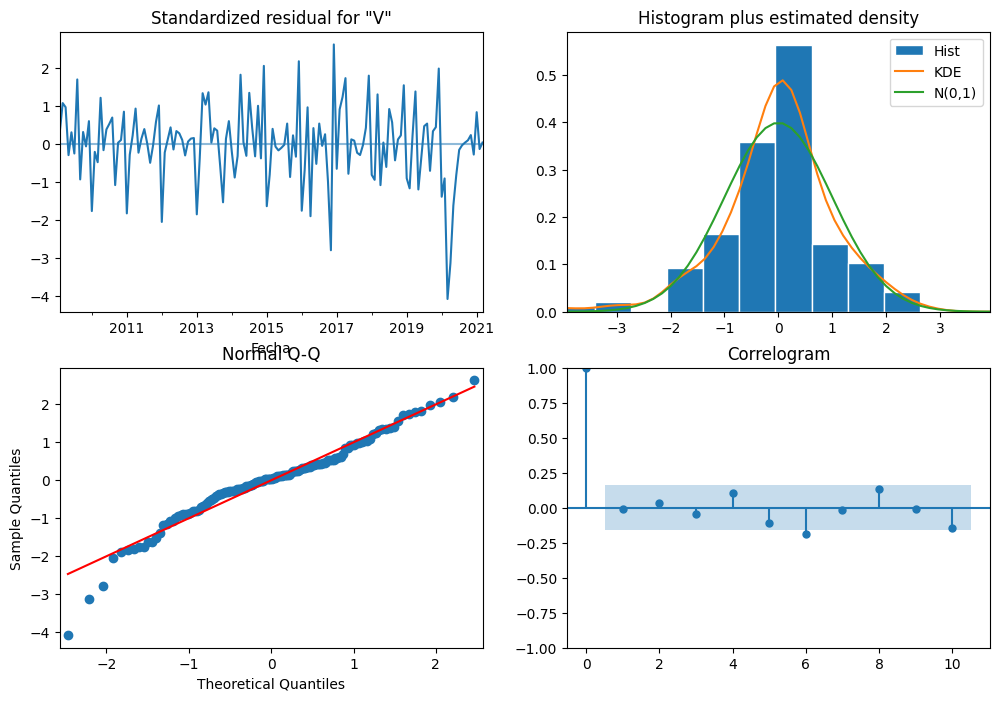


Modelo ARIMA(1, 1, 2)


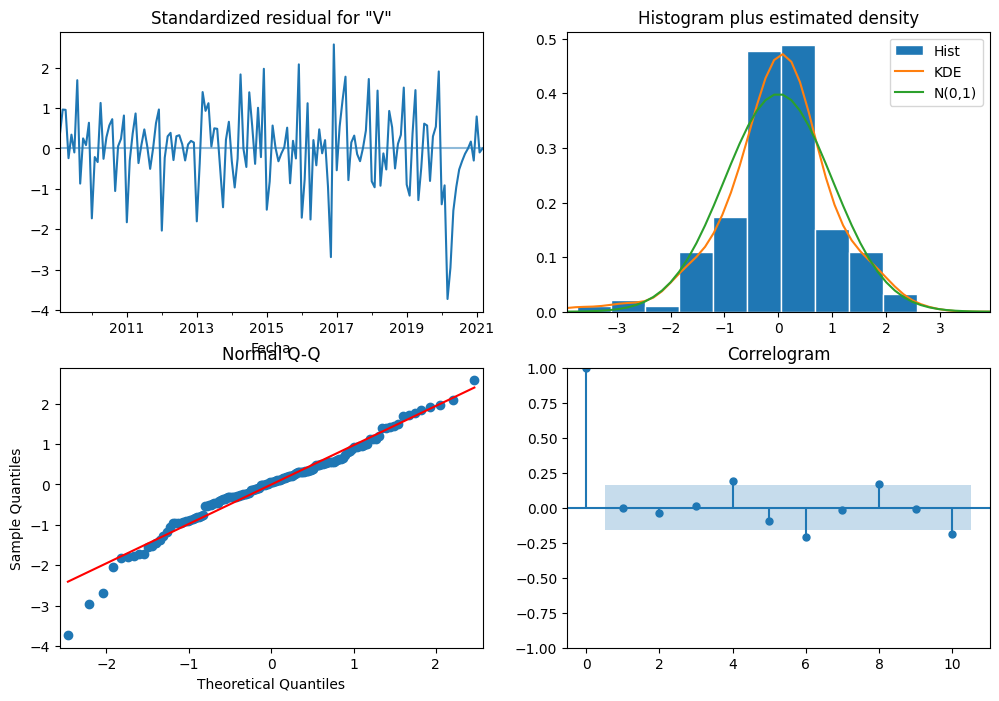


Modelo ARIMA(2, 1, 2)


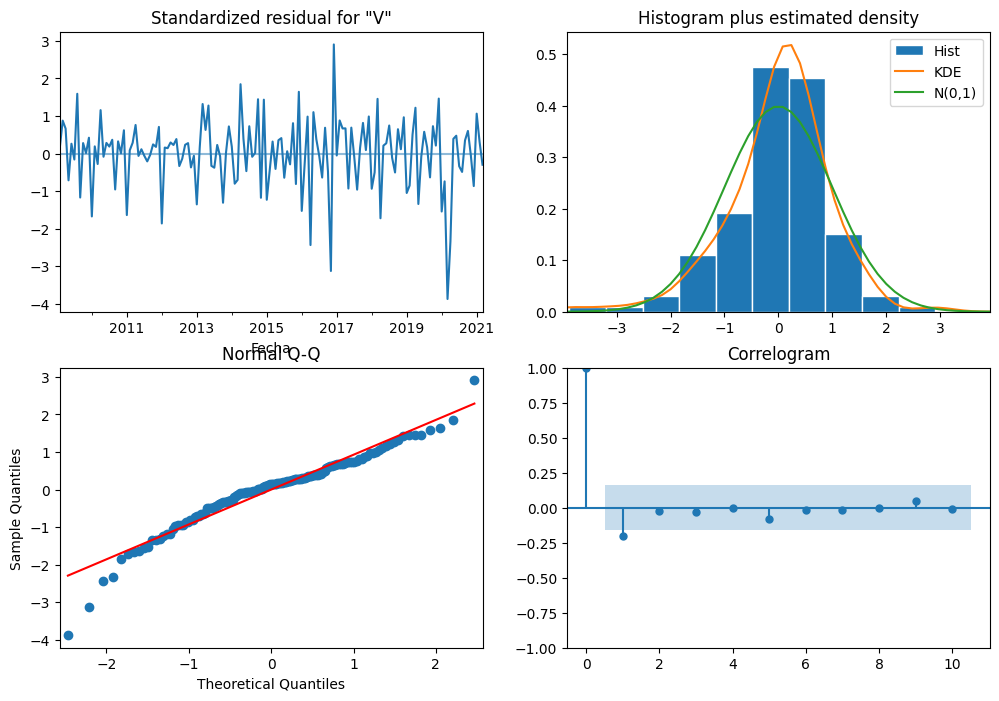


Modelo ARIMA(3, 1, 1)


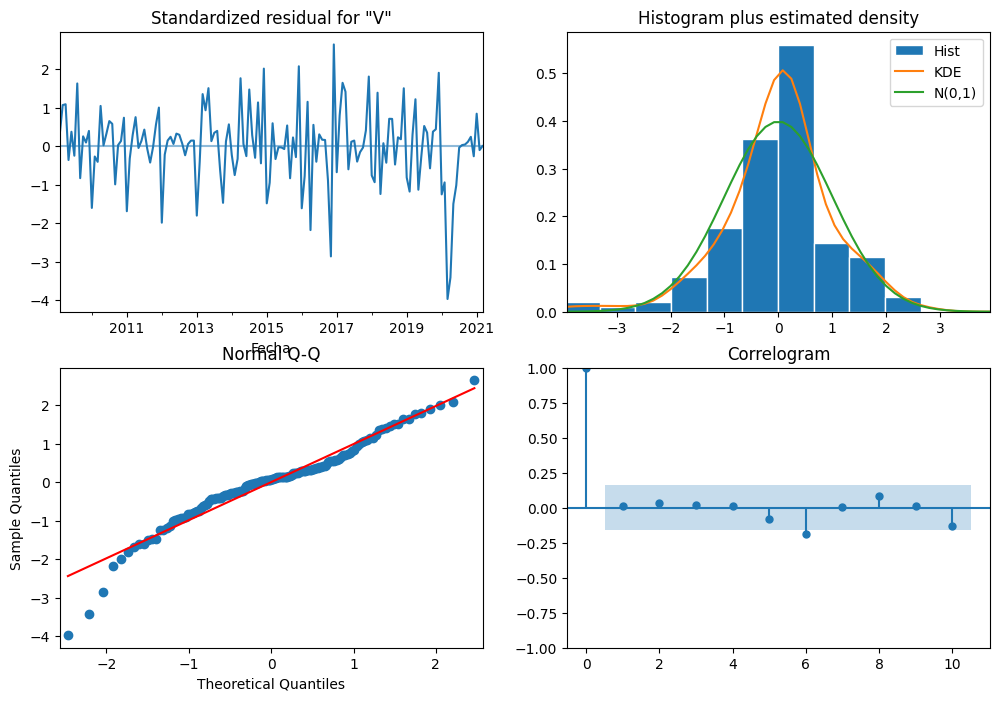

In [27]:
modelos = [
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2),
    (3,1,1)
]

for orden in modelos:

    modelo = ARIMA(train_serie, order=orden).fit()

    print(f"\nModelo ARIMA{orden}")

    modelo.plot_diagnostics(figsize=(12,8))

    plt.show()

In [28]:
from statsmodels.tsa.arima.model import ARIMA

resultados = []

for orden in modelos:

    modelo = ARIMA(train_serie, order=orden)
    modelo_fit = modelo.fit()

    resultados.append({
        "Modelo": f"ARIMA{orden}",
        "AIC": modelo_fit.aic,
        "BIC": modelo_fit.bic
    })

resultados = pd.DataFrame(resultados)

resultados.sort_values("AIC")

,Modelo,AIC,BIC
3,"ARIMA(2, 1, 2)",3185.051812,3199.969845
4,"ARIMA(3, 1, 1)",3200.407737,3215.325771
1,"ARIMA(2, 1, 1)",3201.045082,3212.979508
2,"ARIMA(1, 1, 2)",3203.638343,3215.572769
0,"ARIMA(1, 1, 1)",3204.009497,3212.960316


In [29]:
mejor_arima = ARIMA(train_serie, order=(2,1,2)).fit()

pred_arima = mejor_arima.forecast(steps=len(test_serie))

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test_serie, pred_arima)

rmse_arima = np.sqrt(
    mean_squared_error(test_serie, pred_arima)
)

print("ARIMA (2,1,2)")
print(f"MAE : {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")

ARIMA (2,1,2)
MAE : 39227.19
RMSE: 43606.36


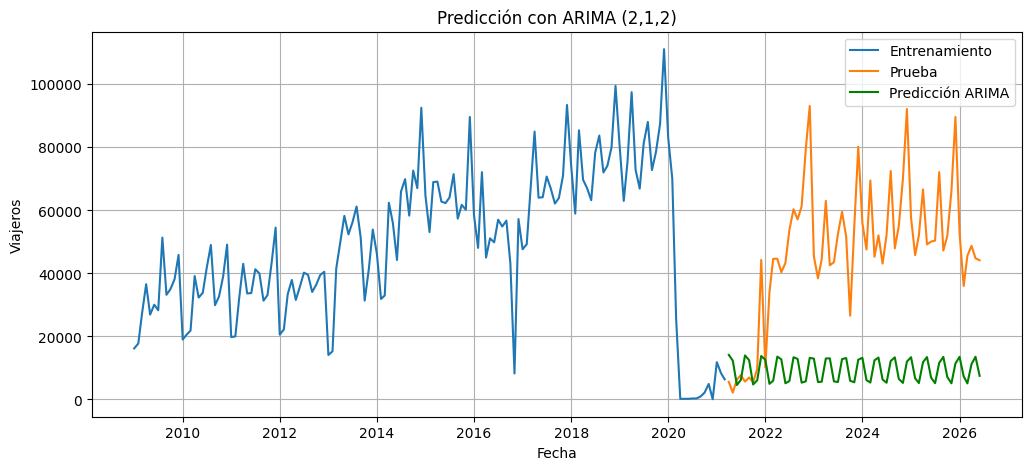

In [31]:
plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index,
         pred_arima,
         label="Predicción ARIMA",
         color="green")

plt.title("Predicción con ARIMA (2,1,2)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

## Modelos alternativos

### Holt-Winters

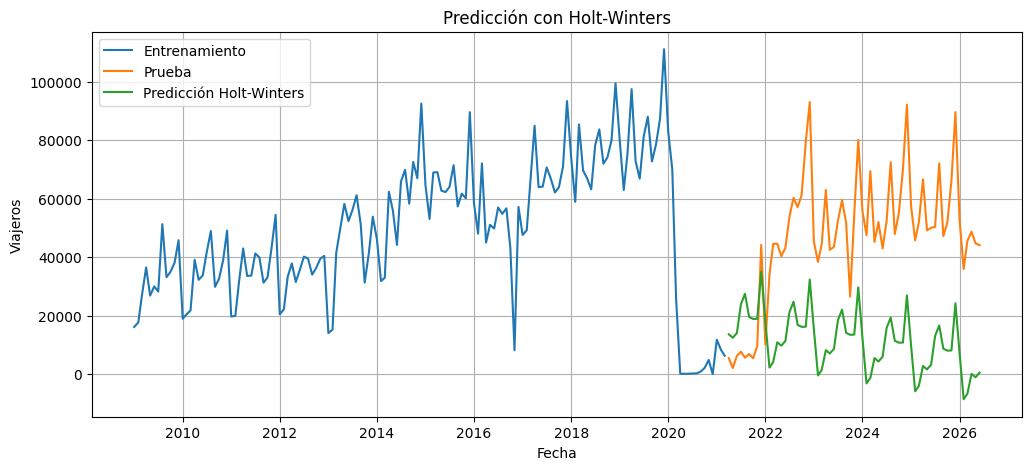

Holt-Winters
MAE : 39493.57168607674
RMSE: 42547.66193539789


In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw = ExponentialSmoothing(
    train_serie,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

pred_hw = modelo_hw.forecast(len(test_serie))

mae_hw = mean_absolute_error(test_serie, pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test_serie, pred_hw))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_hw, label="Predicción Holt-Winters")

plt.title("Predicción con Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Holt-Winters")
print("MAE :", mae_hw)
print("RMSE:", rmse_hw)

### Prophet

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
15:08:43 - cmdstanpy - INFO - Chain [1] start processing
15:08:43 - cmdstanpy - INFO - Chain [1] done processing


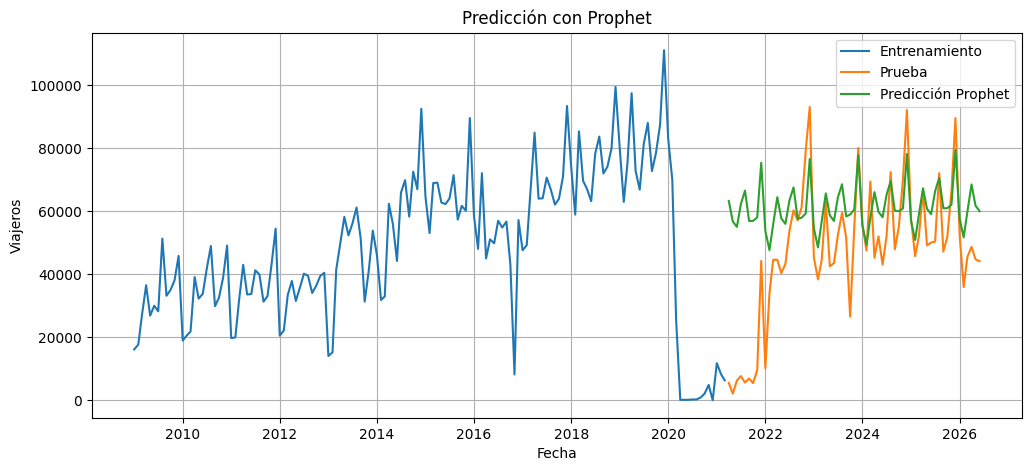

Prophet
MAE : 16754.365621193436
RMSE: 23140.28075969808


In [33]:
from prophet import Prophet

prophet_train = train_serie.reset_index()
prophet_train.columns = ["ds", "y"]

modelo_prophet = Prophet()

modelo_prophet.fit(prophet_train)

future = modelo_prophet.make_future_dataframe(
    periods=len(test_serie),
    freq="MS"
)

forecast = modelo_prophet.predict(future)

pred_prophet = forecast.tail(len(test_serie))["yhat"].values

mae_prophet = mean_absolute_error(test_serie, pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test_serie, pred_prophet))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_prophet, label="Predicción Prophet")

plt.title("Predicción con Prophet")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Prophet")
print("MAE :", mae_prophet)
print("RMSE:", rmse_prophet)

### Seasonal Naive

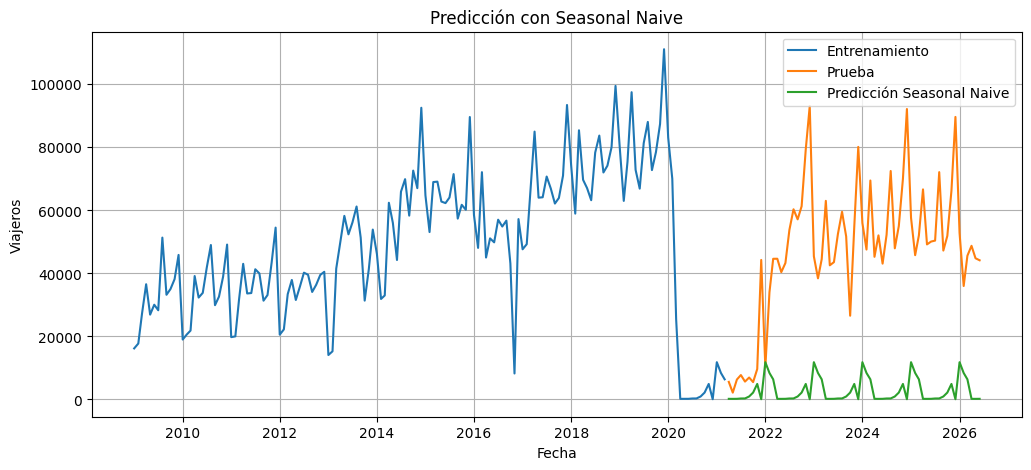

Seasonal Naive
MAE : 44707.230288275096
RMSE: 49660.58809058914


In [34]:
pred_naive = np.tile(
    train_serie.iloc[-12:].values,
    int(np.ceil(len(test_serie)/12))
)

pred_naive = pred_naive[:len(test_serie)]

pred_naive = pd.Series(
    pred_naive,
    index=test_serie.index
)

mae_naive = mean_absolute_error(test_serie, pred_naive)
rmse_naive = np.sqrt(mean_squared_error(test_serie, pred_naive))

plt.figure(figsize=(12,5))

plt.plot(train_serie, label="Entrenamiento")
plt.plot(test_serie, label="Prueba")
plt.plot(test_serie.index, pred_naive, label="Predicción Seasonal Naive")

plt.title("Predicción con Seasonal Naive")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()

print("Seasonal Naive")
print("MAE :", mae_naive)
print("RMSE:", rmse_naive)

In [35]:
comparacion = pd.DataFrame({
    "Modelo": [
        "ARIMA (2,1,2)",
        "Holt-Winters",
        "Prophet",
        "Seasonal Naive"
    ],
    "MAE": [
        mae_arima,
        mae_hw,
        mae_prophet,
        mae_naive
    ],
    "RMSE": [
        rmse_arima,
        rmse_hw,
        rmse_prophet,
        rmse_naive
    ]
})

comparacion = comparacion.sort_values("RMSE")

print(comparacion)

           Modelo           MAE          RMSE
2         Prophet  16754.365621  23140.280760
1    Holt-Winters  39493.571686  42547.661935
0   ARIMA (2,1,2)  39227.193050  43606.356953
3  Seasonal Naive  44707.230288  49660.588091


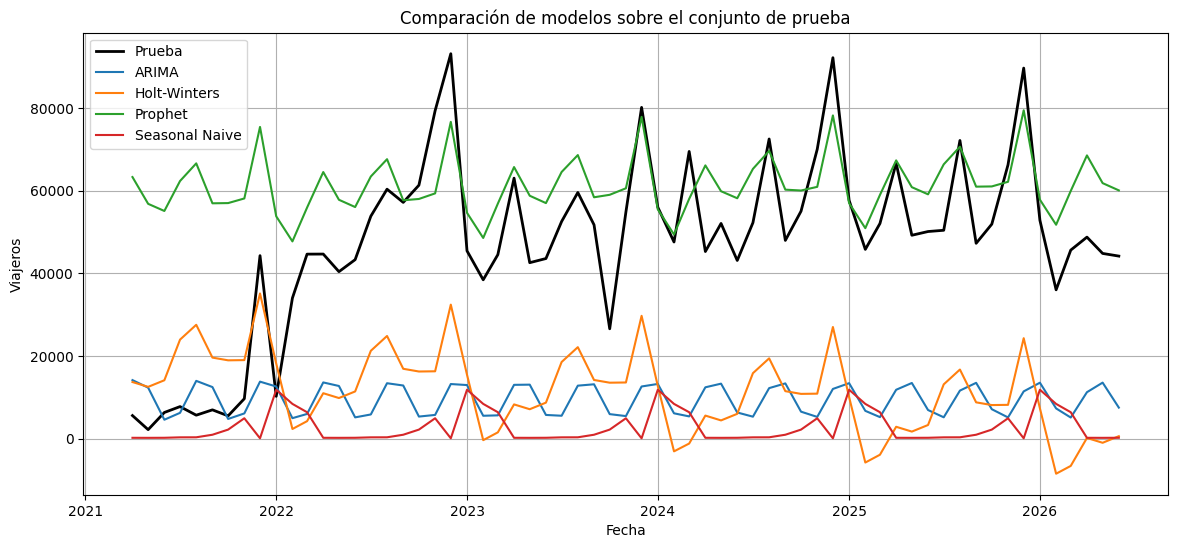

In [36]:
plt.figure(figsize=(14,6))

plt.plot(test_serie, label="Prueba", color="black", linewidth=2)

plt.plot(test_serie.index, pred_arima, label="ARIMA")
plt.plot(test_serie.index, pred_hw, label="Holt-Winters")
plt.plot(test_serie.index, pred_prophet, label="Prophet")
plt.plot(test_serie.index, pred_naive, label="Seasonal Naive")

plt.title("Comparación de modelos sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")

plt.legend()
plt.grid(True)

plt.show()